# Tweets de Donald Trump y Bitcoin

- **¿Los tweets de Donald Trump pueden predecir el precio de Bitcoin?**

El enfoque del trabajo gira en torno a esta pregunta, y daremos una respuesta en base a los datos y la informacion que podamos obtener de los datasets provenientes de diferentes APIs. A lo largo del proyecto, recopilaremos estos datos, generaremos nuevas variables, utilizaremos los modelos que creamos adecuados para obtener insights, y daremos una conclusion.

Sumaremos algunas variables macroeconomicas: la tasa de interes de la Reserva Federal y la oferta monetaria M2, con el fin de enriquecer el modelo y encontrar otras posibles correlaciones.

La pregunta del principio nos lleva a otras preguntas que son igualmente importantes. En el mundo real, predecir el precio de un activo financiero o una criptomoneda es practicamente imposible porque nadie posee la bola de cristal, hay muchas variables que influyen directa e indirectamente en el precio. Esto lo podemos traducir en la siguiente pregunta:

- **¿Disponemos de la suficiente informacion para hacer el analisis correcto?**

Sin anticipar la respuesta, podemos llegar a pensar que NO. Dicho esto, intentar predecir un precio con un tweet es una tarea casi imposible. Seria mas sensato pensar en esto desde una variacion porcentual diaria, por lo tanto, vamos a corregir la pregunta del principio:

- **¿Los tweets de Donald Trump tienen impacto en la variacion porcentual diara de Bitcoin?**

Tambien podemos pensar que el impacto de cada tweet podria durar varios dias, es decir, influir en la volatibilidad de los dias posteriores, y podemos traducir esto en otra pregunta:

- **¿Los tweets de Donald Trump tienen impacto en la volatibilidad Bitcoin?**

### Podemos encontrar la presentacion de diapositivas en el siguiente link:
https://docs.google.com/presentation/d/15wAM83AaVVitTDSFlqB-epXCO1drlCR13zDXeEUZMYk

Empezamos con el proyecto. Importamos las librerias.

In [ ]:
# Importamos las librerias
import pandas as pd
import numpy as np
import os

# API de KaggleHub para obtener los datos de los tweets de Donald Trump

In [ ]:
# API de Kaggle
!pip install kagglehub

In [ ]:
# Importamos el token de Kaggle

from google.colab import files
files.upload()


Saving API kaggle.json to API kaggle.json


{'API kaggle.json': b'{"username":"agusban9761","key":"31baafd4bf6a5133d715c86e32053624"}'}

In [ ]:
# Movemos el token a la carpeta correcta
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [ ]:
# Importamos kagglehub

import kagglehub

# Descargamos el dataset de Tweets de Donald Trump
path = kagglehub.dataset_download("codebreaker619/donald-trump-tweets-dataset")

print("Ruta de los archivos:", path)

100%|██████████| 4.25M/4.25M [00:00<00:00, 33.7MB/s]

Extracting files...


Ruta de los archivos: /root/.cache/kagglehub/datasets/codebreaker619/donald-trump-tweets-dataset/versions/1


In [ ]:
# Hacemos print de los archivos de la carpeta

print(os.listdir(path))


['tweets.csv']


# Traemos los datos de los tweets de Donald Trump

In [ ]:
# Definimos df como nombre del dataset 'tweets.csv'

df = pd.read_csv(os.path.join(path, "tweets.csv"))
df.head()

,id,text,isRetweet,isDeleted,device,favorites,retweets,date,isFlagged
0,98454970654916608,Republicans and Democrats have both created ou...,f,f,TweetDeck,49,255,2011-08-02 18:07:48,f
1,1234653427789070336,I was thrilled to be back in the Great city of...,f,f,Twitter for iPhone,73748,17404,2020-03-03 01:34:50,f
2,1218010753434820614,RT @CBS_Herridge: READ: Letter to surveillance...,t,f,Twitter for iPhone,0,7396,2020-01-17 03:22:47,f
3,1304875170860015617,The Unsolicited Mail In Ballot Scam is a major...,f,f,Twitter for iPhone,80527,23502,2020-09-12 20:10:58,f
4,1218159531554897920,RT @MZHemingway: Very friendly telling of even...,t,f,Twitter for iPhone,0,9081,2020-01-17 13:13:59,f


In [ ]:
# Shape
df.shape

(56571, 9)

In [ ]:
# Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56571 entries, 0 to 56570
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         56571 non-null  int64 
 1   text       56571 non-null  object
 2   isRetweet  56571 non-null  object
 3   isDeleted  56571 non-null  object
 4   device     56571 non-null  object
 5   favorites  56571 non-null  int64 
 6   retweets   56571 non-null  int64 
 7   date       56571 non-null  object
 8   isFlagged  56571 non-null  object
dtypes: int64(3), object(6)
memory usage: 3.9+ MB


In [ ]:
# Cambiamos a tipo fecha la columna 'date'

df['date'] = pd.to_datetime(df['date'], errors='coerce')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56571 entries, 0 to 56570
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   id         56571 non-null  int64         
 1   text       56571 non-null  object        
 2   isRetweet  56571 non-null  object        
 3   isDeleted  56571 non-null  object        
 4   device     56571 non-null  object        
 5   favorites  56571 non-null  int64         
 6   retweets   56571 non-null  int64         
 7   date       56571 non-null  datetime64[ns]
 8   isFlagged  56571 non-null  object        
dtypes: datetime64[ns](1), int64(3), object(5)
memory usage: 3.9+ MB


In [ ]:
# Vamos a transformar la variable 'date' para excluir la hora, minutos y segunos de cada tweet

df['date'] = df['date'].dt.floor('D')

In [ ]:
# Filtramos los tweets segun palabras relacionadas al sector economico y financiero
# Primero elegimos las palabras clave

palabras = [
    # cripto y blockchain
    "bitcoin", "crypto", "cryptocurrency", "blockchain", "ethereum", "token",
    "btc", "ethereum", "wallet", "mining", "digital currency",

    # economia y finanzas
    "economy", "market", "inflation", "recession", "interest rate", "rates",
    "federal reserve", "fed", "treasury", "stock", "bond", "investment",
    "investor", "trading", "exchange", "wall street", "bank", "banks",

    # politica economica y fiscal
    "tax", "taxes", "IRS", "deficit", "debt", "spending", "budget", "stimulus", "printing money",
    "money supply", "dollar", "currency", "fiat",

    # geopolitica
    "trade", "tariff", "sanction", "oil", "energy", "price", "supply"]

# Creamos condicion_palabras para evitar que algunos tweets puedan 'colarse' incluso con filtro

condicion_palabras = r"\b(" + "|".join(palabras) + r")\b"

# Creamos una mascara para el dataframe

mask = df["text"].str.contains(condicion_palabras, case=False, na=False)
df_mask = df[mask]

/tmp/ipython-input-2995389597.py:27: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  mask = df["text"].str.contains(condicion_palabras, case=False, na=False)


- **Nota**: Cuando usamos una mascara para filtrar los tweets, este depende de palabras arbitrarias relacionadas al ambito economico y financiero, sin embargo algunos tweets excluidos podrian ser relevantes y tener un impacto en el analisis.
Al mismo tiempo, tweets que incluyan algunas de las palabras del filtro pero que no esten relacionados con el ambito economico y financiero tambien podrian llegar a tener un impacto no deseado en el analisis.

In [ ]:
# Orden por fecha

df_mask = df_mask.sort_values(by='date', ascending=False)

df_mask

,id,text,isRetweet,isDeleted,device,favorites,retweets,date,isFlagged
2676,1345160427337084931,"Because of the Trump Administration, hospitals...",f,f,Twitter for iPhone,304112,64916,2021-01-02,f
2649,1344852043681435648,Finished off the year with the highest Stock M...,f,f,Twitter for iPhone,377120,59151,2021-01-01,f
2630,1344160786252525568,The Wall Street Journal’s very boring &amp; in...,f,f,Twitter for iPhone,161868,34953,2020-12-30,f
2610,1344029894242656261,RT @washingtonpost: The House votes at Trump’s...,t,f,Twitter for iPhone,0,10721,2020-12-29,f
2550,1343672540313636867,RT @LindseyGrahamSC: @realDonaldTrump Congress...,t,f,Twitter for iPhone,0,13478,2020-12-28,f
...,...,...,...,...,...,...,...,...,...
14117,88617765589630976,"Congress is back.TIME TO CUT, CAP AND BALANCE....",f,f,Twitter Web Client,78,225,2011-07-06,f
13399,17254625071,"""""""Trading Shots with Donald Trump""""--a great ...",f,f,Twitter Web Client,9,27,2010-06-28,f
13412,15518022208,Tonight I trade places with Larry King @kingst...,f,f,Twitter Web Client,11,34,2010-06-05,f
13279,5069623974,"Hear Donald Trump discuss big gov spending, ba...",f,f,Twitter Web Client,28,7,2009-10-22,f


In [ ]:
# Shzpe

df_mask.shape

(3694, 9)

In [ ]:
# Nuestros datos del Bitcoin empiezan en 2015-01-01 por lo tanto vamos a considerar los tweets a partir de esta fecha

df_mask = df_mask[df_mask["date"] >= "2015-01-01"]

df_mask

,id,text,isRetweet,isDeleted,device,favorites,retweets,date,isFlagged
2676,1345160427337084931,"Because of the Trump Administration, hospitals...",f,f,Twitter for iPhone,304112,64916,2021-01-02,f
2649,1344852043681435648,Finished off the year with the highest Stock M...,f,f,Twitter for iPhone,377120,59151,2021-01-01,f
2630,1344160786252525568,The Wall Street Journal’s very boring &amp; in...,f,f,Twitter for iPhone,161868,34953,2020-12-30,f
2610,1344029894242656261,RT @washingtonpost: The House votes at Trump’s...,t,f,Twitter for iPhone,0,10721,2020-12-29,f
2550,1343672540313636867,RT @LindseyGrahamSC: @realDonaldTrump Congress...,t,f,Twitter for iPhone,0,13478,2020-12-28,f
...,...,...,...,...,...,...,...,...,...
38279,557928491073933313,If Scotland would have gone independent predic...,f,f,Twitter Web Client,122,171,2015-01-21,f
38280,557752640919330817,"""""""@Missey5Mae: I think if a GOP candidate rea...",f,f,Twitter for Android,68,28,2015-01-21,f
38543,553853483016015872,"""""""@danhalen: DonaldTrump great job on Letterm...",f,f,Twitter for Android,32,22,2015-01-10,f
38711,552554946684792832,I look forward to going to the Land Investment...,f,f,Twitter Web Client,39,38,2015-01-06,f


In [ ]:
# Ahora nos interesa analizar el sentimiento de los tweets desde el punto de vista economico y financiero
# Vamos a proceder importando la libreria pipeline

!pip install transformers torch

from transformers import pipeline

# Usamos el modelo FinBERT para analizar el sentimiento de cada tweet
# FinBERT fue entrenado con reportes de compañías y noticias de política económica para interpretar frases semanticamente

modelo_sentimiento = pipeline("sentiment-analysis", model="ProsusAI/finbert",device=0)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Device set to use cpu


- **Nota**: Los modelos de sentimiento son representativos del sentimiento pero eso no significa que esten relacionados necesariamente al ambito economico y financiero.

In [ ]:
# Agregamos la variable de sentimiento 'sentiment' al dataframe
# Esto nos dice si tweet tuvo un sentimiento positivo, negativo, o neutro

df_mask["sentiment"] = df_mask["text"].apply(lambda x: modelo_sentimiento(str(x))[0]["label"])

# Agregamos la variable de puntaje de sentimiento 'sentiment_score' al dataframe
# Esto nos dice un valor entre 0 y 1 que refleja el nivel de sentimiento de un tweet

df_mask["sentiment_score"] = df_mask["text"].apply(lambda x: modelo_sentimiento(str(x))[0]["score"])


/tmp/ipython-input-2028214376.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_mask["sentiment"] = df_mask["text"].apply(lambda x: modelo_sentimiento(str(x))[0]["label"])
/tmp/ipython-input-2028214376.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_mask["sentiment_score"] = df_mask["text"].apply(lambda x: modelo_sentimiento(str(x))[0]["score"])


In [ ]:
df_mask

,id,text,isRetweet,isDeleted,device,favorites,retweets,date,isFlagged,sentiment,sentiment_score
2676,1345160427337084931,"Because of the Trump Administration, hospitals...",f,f,Twitter for iPhone,304112,64916,2021-01-02,f,neutral,0.845474
2649,1344852043681435648,Finished off the year with the highest Stock M...,f,f,Twitter for iPhone,377120,59151,2021-01-01,f,positive,0.556386
2630,1344160786252525568,The Wall Street Journal’s very boring &amp; in...,f,f,Twitter for iPhone,161868,34953,2020-12-30,f,negative,0.619066
2610,1344029894242656261,RT @washingtonpost: The House votes at Trump’s...,t,f,Twitter for iPhone,0,10721,2020-12-29,f,neutral,0.804857
2550,1343672540313636867,RT @LindseyGrahamSC: @realDonaldTrump Congress...,t,f,Twitter for iPhone,0,13478,2020-12-28,f,positive,0.594229
...,...,...,...,...,...,...,...,...,...,...,...
38279,557928491073933313,If Scotland would have gone independent predic...,f,f,Twitter Web Client,122,171,2015-01-21,f,neutral,0.656215
38280,557752640919330817,"""""""@Missey5Mae: I think if a GOP candidate rea...",f,f,Twitter for Android,68,28,2015-01-21,f,neutral,0.919664
38543,553853483016015872,"""""""@danhalen: DonaldTrump great job on Letterm...",f,f,Twitter for Android,32,22,2015-01-10,f,positive,0.524110
38711,552554946684792832,I look forward to going to the Land Investment...,f,f,Twitter Web Client,39,38,2015-01-06,f,neutral,0.870766


In [ ]:
# Eliminaremos los posibles tweets duplicados
df_mask = df_mask.drop_duplicates()

# Verificamos
df_mask.shape

(2585, 11)

In [ ]:
# Ahora agrupamos los dias para ver los dias que tienen mas de 1 tweet

tweets_count = df_mask.groupby("date").size().reset_index(name="Tweet_Count").sort_values(by="date", ascending=True)
tweets_count

,date,Tweet_Count
0,2015-01-02,1
1,2015-01-06,1
2,2015-01-10,1
3,2015-01-21,4
4,2015-01-23,2
...,...,...
1163,2020-12-28,1
1164,2020-12-29,1
1165,2020-12-30,1
1166,2021-01-01,1


In [ ]:
# Renombramos las columna 'date'

tweets_count = tweets_count.rename(columns={
    'date': 'Date',
})

In [ ]:
# Chequeamos las columnas

tweets_count.columns

Index(['Date', 'Tweet_Count'], dtype='object')

Algunos dias tienen mas de 1 tweet, asi que decidiremos elegir el puntaje mas alto de ese dia para generar un dataframe, tal que a cada dia le corresponda solo un puntaje de sentimiento.

In [ ]:
# Usamos groupby() y max()

tweets_score = df_mask.groupby("date")["sentiment_score"].max().reset_index().sort_values(by="date", ascending=True)

tweets_score.head()

,date,sentiment_score
0,2015-01-02,0.818184
1,2015-01-06,0.870766
2,2015-01-10,0.524110
3,2015-01-21,0.919664
4,2015-01-23,0.793901


Ahora buscamos el sentimiento para el maximo puntaje de sentimiento por dia.

In [ ]:
# Buscamos el index del puntaje mas alto para cada tweet

idx = df_mask.groupby("date")["sentiment_score"].idxmax()

Seleccionamos el sentimiento segun el puntaje y con esto podemos tener el dataframe con las columnas que realmente nos interesan.

In [ ]:
# Usamos .loc
tweets_sent = df_mask.loc[idx, ["date", "sentiment", "sentiment_score"]].sort_values(by="date", ascending=True)

tweets_sent

,date,sentiment,sentiment_score
39085,2015-01-02,neutral,0.818184
38711,2015-01-06,neutral,0.870766
38543,2015-01-10,positive,0.524110
38280,2015-01-21,neutral,0.919664
38250,2015-01-23,neutral,0.793901
...,...,...,...
2550,2020-12-28,positive,0.594229
2610,2020-12-29,neutral,0.804857
2630,2020-12-30,negative,0.619066
2649,2021-01-01,positive,0.556386


Renombramos las columnas.

In [ ]:
tweets_sent.columns

Index(['date', 'sentiment', 'sentiment_score'], dtype='object')

In [ ]:
# Usamos .rename()
tweets_sent = tweets_sent.rename(columns={
    'date': 'Date',
    'sentiment': 'Sentiment',
    'sentiment_score': 'Sentiment_Score'
})

tweets_sent.columns

Index(['Date', 'Sentiment', 'Sentiment_Score'], dtype='object')

# API de yfinance para obtener los datos del precio de Bitcoin

In [ ]:
# API de yfinance

!pip install yfinance

# Libreria

import yfinance as yf

In [ ]:
# Descargamos el  dataset de Bitcoin

btc = yf.download("BTC-USD", start="2015-01-01", end="2021-01-07")

/tmp/ipython-input-3023531795.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  btc = yf.download("BTC-USD", start="2015-01-01", end="2021-01-07")
[*********************100%***********************]  1 of 1 completed


In [ ]:
# Vemos el dataset

btc.head()

Price,Close,High,Low,Open,Volume
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
Date,,,,,
2015-01-01,314.248993,320.434998,314.002991,320.434998,8036550
2015-01-02,315.032013,315.838989,313.565002,314.079010,7860650
2015-01-03,281.082001,315.149994,281.082001,314.846008,33054400
2015-01-04,264.195007,287.230011,257.612000,281.145996,55629100
2015-01-05,274.473999,278.341003,265.084015,265.084015,43962800


In [ ]:
# Reset del index para tener la fecha como columna

btc = btc.reset_index()

In [ ]:
# Chequeamos las columnas

btc.columns

MultiIndex([(  'Date',        ''),
            ( 'Close', 'BTC-USD'),
            (  'High', 'BTC-USD'),
            (   'Low', 'BTC-USD'),
            (  'Open', 'BTC-USD'),
            ('Volume', 'BTC-USD')],
           names=['Price', 'Ticker'])

In [ ]:
# Convertimos las columnas MultiIndex en Index

btc.columns = btc.columns.droplevel('Ticker')

btc.columns

Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object', name='Price')

In [ ]:
# Shape

btc.shape

(2198, 6)

In [ ]:
# Info

btc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2198 entries, 0 to 2197
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    2198 non-null   datetime64[ns]
 1   Close   2198 non-null   float64       
 2   High    2198 non-null   float64       
 3   Low     2198 non-null   float64       
 4   Open    2198 non-null   float64       
 5   Volume  2198 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 103.2 KB


In [ ]:
# Ahora calculamos la variacion porcentual del bitcoin en base al precio de cierre con .pct_change()

btc['Close_Var'] = btc[ 'Close'].pct_change()

btc.head()

Price,Date,Close,High,Low,Open,Volume,Close_Var
0,2015-01-01,314.248993,320.434998,314.002991,320.434998,8036550,NaN
1,2015-01-02,315.032013,315.838989,313.565002,314.079010,7860650,0.002492
2,2015-01-03,281.082001,315.149994,281.082001,314.846008,33054400,-0.107767
3,2015-01-04,264.195007,287.230011,257.612000,281.145996,55629100,-0.060079
4,2015-01-05,274.473999,278.341003,265.084015,265.084015,43962800,0.038907


In [ ]:
# Ahora calculamos la volatilidad de 5 días con .rolling(5)
# Usamos .std() para obtener la desviacion estandar de esos dias
# Usamos .shift(-5) para desplazar esos dias hacia adelante, ya que el modelo no puede ver el futuro

btc["Vol_5d"] = btc['Close_Var'].rolling(5).std().shift(-5)


In [ ]:
# Tambien aplicamos .shift(-1) en 'Close_Var' para que esa variacion porcentual corresponda al dia anterior

btc['Close_Var'] = btc['Close_Var'].shift(-1)

In [ ]:
# Vemos el dataframe con .tail(10)
btc.tail(10)

Price,Date,Close,High,Low,Open,Volume,Close_Var,Vol_5d
2188,2020-12-28,27084.808594,27389.111328,26207.640625,26280.822266,49056742893,0.010250,0.038013
2189,2020-12-29,27362.437500,27370.720703,25987.298828,27081.810547,45265946774,0.054034,0.036589
2190,2020-12-30,28840.953125,28937.740234,27360.089844,27360.089844,51287442704,0.005574,0.043823
2191,2020-12-31,29001.720703,29244.876953,28201.992188,28841.574219,46754964848,0.012842,0.046086
2192,2021-01-01,29374.152344,29600.626953,28803.585938,28994.009766,40730301359,0.093726,0.049028
2193,2021-01-02,32127.267578,33155.117188,29091.181641,29376.455078,67865420765,0.020380,NaN
2194,2021-01-03,32782.023438,34608.558594,32052.316406,32129.408203,78665235202,-0.024712,NaN
2195,2021-01-04,31971.914062,33440.218750,28722.755859,32810.949219,81163475344,0.063197,NaN
2196,2021-01-05,33992.429688,34437.589844,30221.187500,31977.041016,67547324782,0.083311,NaN
2197,2021-01-06,36824.363281,36879.699219,33514.035156,34013.613281,75289433811,NaN,NaN


In [ ]:
# Notamos que nos quedan varias filas al final con NAs, por lo que hacemos dropna()
btc = btc.dropna()

btc.tail(10)

Price,Date,Close,High,Low,Open,Volume,Close_Var,Vol_5d
2183,2020-12-23,23241.345703,24024.490234,22802.646484,23781.974609,51146161904,0.021281,0.028350
2184,2020-12-24,23735.949219,23768.337891,22777.597656,23240.203125,41080759713,0.039132,0.029730
2185,2020-12-25,24664.791016,24710.101562,23463.673828,23733.570312,42068395846,0.071853,0.031660
2186,2020-12-26,26437.037109,26718.070312,24522.689453,24677.015625,48332647295,-0.006231,0.023786
2187,2020-12-27,26272.294922,28288.839844,25922.769531,26439.373047,66479895605,0.030927,0.019969
2188,2020-12-28,27084.808594,27389.111328,26207.640625,26280.822266,49056742893,0.010250,0.038013
2189,2020-12-29,27362.437500,27370.720703,25987.298828,27081.810547,45265946774,0.054034,0.036589
2190,2020-12-30,28840.953125,28937.740234,27360.089844,27360.089844,51287442704,0.005574,0.043823
2191,2020-12-31,29001.720703,29244.876953,28201.992188,28841.574219,46754964848,0.012842,0.046086
2192,2021-01-01,29374.152344,29600.626953,28803.585938,28994.009766,40730301359,0.093726,0.049028


In [ ]:
# Ahora corroboramos los valores nulos

btc.isna().sum()

,0
Price,
Date,0
Close,0
High,0
Low,0
Open,0
Volume,0
Close_Var,0
Vol_5d,0


# API de FRED para obtener los datos de la Reserva Federal de Estados Unidos

In [ ]:
# Importamos la libreria

!pip install fredapi

from fredapi import Fred

# Usamos la API key

fred = Fred(api_key="fba79cca7aa2b42f1eb3fba121341973")

In [ ]:
# Traemos los datos de la tasa de interes

i_rate = fred.get_series("FEDFUNDS")

i_rate = i_rate.to_frame("I_Rate")

# Convertimos los datos mensuales a una frecuencia diaria

i_rate = i_rate.resample("D").ffill()

i_rate

,I_Rate
1954-07-01,0.80
1954-07-02,0.80
1954-07-03,0.80
1954-07-04,0.80
1954-07-05,0.80
...,...
2025-10-28,4.09
2025-10-29,4.09
2025-10-30,4.09
2025-10-31,4.09


In [ ]:
# Traemos los datos de la Oferta Monetaria M2 (Money Supply)

m2 = fred.get_series("M2SL")

# Convertimos los datos mensuales a una frecuencia diaria

m2 = m2.to_frame("M2").resample("D").ffill()

m2

,M2
1959-01-01,286.6
1959-01-02,286.6
1959-01-03,286.6
1959-01-04,286.6
1959-01-05,286.6
...,...
2025-09-27,22212.5
2025-09-28,22212.5
2025-09-29,22212.5
2025-09-30,22212.5


In [ ]:
# Primero hacemos merge con el dataframe de Bitcoin y la tasa de interes

btc_fed = btc.merge(i_rate, left_on="Date", right_index=True, how="left")

# Ahora hacemos merge con el resto de variables

btc_fed = btc_fed.merge(m2, left_on="Date", right_index=True, how="left")

# Al hacer merge, los datos se reducen a fechas a partir del 2015

btc_fed

,Date,Close,High,Low,Open,Volume,Close_Var,Vol_5d,I_Rate,M2
0,2015-01-01,314.248993,320.434998,314.002991,320.434998,8036550,0.002492,0.065501,0.11,11787.8
1,2015-01-02,315.032013,315.838989,313.565002,314.079010,7860650,-0.107767,0.068376,0.11,11787.8
2,2015-01-03,281.082001,315.149994,281.082001,314.846008,33054400,-0.060079,0.047742,0.11,11787.8
3,2015-01-04,264.195007,287.230011,257.612000,281.145996,55629100,0.038907,0.032610,0.11,11787.8
4,2015-01-05,274.473999,278.341003,265.084015,265.084015,43962800,0.042682,0.043393,0.11,11787.8
...,...,...,...,...,...,...,...,...,...,...
2188,2020-12-28,27084.808594,27389.111328,26207.640625,26280.822266,49056742893,0.010250,0.038013,0.09,19133.0
2189,2020-12-29,27362.437500,27370.720703,25987.298828,27081.810547,45265946774,0.054034,0.036589,0.09,19133.0
2190,2020-12-30,28840.953125,28937.740234,27360.089844,27360.089844,51287442704,0.005574,0.043823,0.09,19133.0
2191,2020-12-31,29001.720703,29244.876953,28201.992188,28841.574219,46754964848,0.012842,0.046086,0.09,19133.0


# Merge - Combinamos los datasets

In [ ]:
# Primero hacemos merge con el dataframe de btc y tweet_count

df_btc = btc_fed.merge(tweets_count, on='Date',  how='left')

# Ahora hacemos merge con tweets_sent

df_btc = df_btc.merge(tweets_sent, on='Date',  how='left')

df_btc

,Date,Close,High,Low,Open,Volume,Close_Var,Vol_5d,I_Rate,M2,Tweet_Count,Sentiment,Sentiment_Score
0,2015-01-01,314.248993,320.434998,314.002991,320.434998,8036550,0.002492,0.065501,0.11,11787.8,NaN,NaN,NaN
1,2015-01-02,315.032013,315.838989,313.565002,314.079010,7860650,-0.107767,0.068376,0.11,11787.8,1.0,neutral,0.818184
2,2015-01-03,281.082001,315.149994,281.082001,314.846008,33054400,-0.060079,0.047742,0.11,11787.8,NaN,NaN,NaN
3,2015-01-04,264.195007,287.230011,257.612000,281.145996,55629100,0.038907,0.032610,0.11,11787.8,NaN,NaN,NaN
4,2015-01-05,274.473999,278.341003,265.084015,265.084015,43962800,0.042682,0.043393,0.11,11787.8,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2188,2020-12-28,27084.808594,27389.111328,26207.640625,26280.822266,49056742893,0.010250,0.038013,0.09,19133.0,1.0,positive,0.594229
2189,2020-12-29,27362.437500,27370.720703,25987.298828,27081.810547,45265946774,0.054034,0.036589,0.09,19133.0,1.0,neutral,0.804857
2190,2020-12-30,28840.953125,28937.740234,27360.089844,27360.089844,51287442704,0.005574,0.043823,0.09,19133.0,1.0,negative,0.619066
2191,2020-12-31,29001.720703,29244.876953,28201.992188,28841.574219,46754964848,0.012842,0.046086,0.09,19133.0,NaN,NaN,NaN


# Diccionario de datos
Antes de seguir, vamos a presentar un diccionario de datos para las variables que estamos utilizando.


| Columna         | Tipo        | Descripcion                                                                                | Fuente                 | Notas                                         |
| ----------------- | ----------- | ------------------------------------------------------------------------------------------ | ---------------------- | --------------------------------------------- |
| `Date`            | date        | Fecha del registro diario                                                                  | Yahoo Finance / Kaggle | Clave temporal del dataset                    |
| `Open`            | float       | Precio de apertura diario de Bitcoin (USD)                                                 | Yahoo Finance          | —                                             |
| `High`            | float       | Precio máximo diario de Bitcoin (USD)                                                      | Yahoo Finance          | —                                             |
| `Low`             | float       | Precio mínimo diario de Bitcoin (USD)                                                      | Yahoo Finance          | —                                             |
| `Close`           | float       | Precio de cierre diario de Bitcoin (USD)                                                   | Yahoo Finance          | —                                             |
| `Volume`          | int         | Volumen diario de transacciones de Bitcoin                                                 | Yahoo Finance          | —                                             |
| `Close_Var`       | float       | Retorno diario de Bitcoin (variación porcentual respecto al día anterior)                  | Calculado              | Proxy de movimiento t+1                       |
| `Vol_5d`          | float       | Volatilidad futura a 5 días (desviación estándar rolling de retornos)                      | Calculado              | Mide magnitud del movimiento futuro           |
| `I_Rate`          | float       | Tasa de interés de la Reserva Federal                                     | FRED                   | Variable macroeconómica                       |
| `M2`              | float       | Oferta monetaria M2 (USD, miles de millones)                                               | FRED                   | Indicador de liquidez sistémica               |
| `Tweet_Count`     | float       | Cantidad de tweets publicados por Donald Trump en ese día                                  | Kaggle (Twitter API)   | Agregado diario                               |
| `Sentiment`       | categorical | Clasificación de sentimiento del tweet (positivo, negativo, neutral) | NLP                    | Variable cualitativa                          |
| `Sentiment_Score` | float       | Puntaje continuo de sentimiento del tweet                                                  | NLP                    | Rango aproximado [-1, 1]; 0 si no hubo tweets |


# EDA - Analisis exploratorio de datos

In [ ]:
# Ahora vemos la info del nuevo dataframe

df_btc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2193 entries, 0 to 2192
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Date             2193 non-null   datetime64[ns]
 1   Close            2193 non-null   float64       
 2   High             2193 non-null   float64       
 3   Low              2193 non-null   float64       
 4   Open             2193 non-null   float64       
 5   Volume           2193 non-null   int64         
 6   Close_Var        2193 non-null   float64       
 7   Vol_5d           2193 non-null   float64       
 8   I_Rate           2193 non-null   float64       
 9   M2               2193 non-null   float64       
 10  Tweet_Count      1167 non-null   float64       
 11  Sentiment        1167 non-null   object        
 12  Sentiment_Score  1167 non-null   float64       
dtypes: datetime64[ns](1), float64(10), int64(1), object(1)
memory usage: 222.9+ KB


In [ ]:
# Podemos notar que hay valores nulos
# Corroboramos con isnull().sum()

df_btc.isnull().sum()

,0
Date,0
Close,0
High,0
Low,0
Open,0
Volume,0
Close_Var,0
Vol_5d,0
I_Rate,0
M2,0


Podemos ver que en los dias que no hubo tweets tenemos valores nulos respecto a cantidad de tweets, sentimiento y puntaje de sentimiento. Por lo tanto, debemos tratar estos datos nulos.

In [ ]:
# Primero hacemos una copia del dataset en una nueva variable

df_clean = df_btc.copy()

Primero reemplazamos los valores nulos de las variables Tweet_Count y Sentiment_Score. Dias sin tweets = 0, por lo tanto, el puntaje de sentimiento = 0.

In [ ]:
# Reemplazamos en las columnas Tweet_Count y Sentiment_Score usando .fillna(0)

df_clean[['Tweet_Count','Sentiment_Score']] = df_clean[['Tweet_Count','Sentiment_Score']].fillna(0)

df_clean.isnull().sum()

,0
Date,0
Close,0
High,0
Low,0
Open,0
Volume,0
Close_Var,0
Vol_5d,0
I_Rate,0
M2,0


Nos queda la variable categorica Sentiment. Primero analizamos:

In [ ]:
# Usamos value_counts()

df_clean['Sentiment'].value_counts(dropna=False)

,count
Sentiment,
NaN,1026
neutral,649
negative,272
positive,246


Vemos que hay tres categorias y una cuarta que corresponde a los valores nulos de los dias sin tweets. Podemos deducir que esos dias tampoco hubo sentimiento, por lo tanto atribuimos a esos valores nulos la categoria 'neutral'

In [ ]:
# Reemplazamos usando .fillna('neutral')
df_clean['Sentiment'] = df_clean['Sentiment'].fillna('neutral')

In [ ]:
# Vemos el dataset final

df_clean

,Date,Close,High,Low,Open,Volume,Close_Var,Vol_5d,I_Rate,M2,Tweet_Count,Sentiment,Sentiment_Score
0,2015-01-01,314.248993,320.434998,314.002991,320.434998,8036550,0.002492,0.065501,0.11,11787.8,0.0,neutral,0.000000
1,2015-01-02,315.032013,315.838989,313.565002,314.079010,7860650,-0.107767,0.068376,0.11,11787.8,1.0,neutral,0.818184
2,2015-01-03,281.082001,315.149994,281.082001,314.846008,33054400,-0.060079,0.047742,0.11,11787.8,0.0,neutral,0.000000
3,2015-01-04,264.195007,287.230011,257.612000,281.145996,55629100,0.038907,0.032610,0.11,11787.8,0.0,neutral,0.000000
4,2015-01-05,274.473999,278.341003,265.084015,265.084015,43962800,0.042682,0.043393,0.11,11787.8,0.0,neutral,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2188,2020-12-28,27084.808594,27389.111328,26207.640625,26280.822266,49056742893,0.010250,0.038013,0.09,19133.0,1.0,positive,0.594229
2189,2020-12-29,27362.437500,27370.720703,25987.298828,27081.810547,45265946774,0.054034,0.036589,0.09,19133.0,1.0,neutral,0.804857
2190,2020-12-30,28840.953125,28937.740234,27360.089844,27360.089844,51287442704,0.005574,0.043823,0.09,19133.0,1.0,negative,0.619066
2191,2020-12-31,29001.720703,29244.876953,28201.992188,28841.574219,46754964848,0.012842,0.046086,0.09,19133.0,0.0,neutral,0.000000


In [ ]:
# Info

df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2193 entries, 0 to 2192
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Date             2193 non-null   datetime64[ns]
 1   Close            2193 non-null   float64       
 2   High             2193 non-null   float64       
 3   Low              2193 non-null   float64       
 4   Open             2193 non-null   float64       
 5   Volume           2193 non-null   int64         
 6   Close_Var        2193 non-null   float64       
 7   Vol_5d           2193 non-null   float64       
 8   I_Rate           2193 non-null   float64       
 9   M2               2193 non-null   float64       
 10  Tweet_Count      2193 non-null   float64       
 11  Sentiment        2193 non-null   object        
 12  Sentiment_Score  2193 non-null   float64       
dtypes: datetime64[ns](1), float64(10), int64(1), object(1)
memory usage: 222.9+ KB


In [ ]:
# Usamos .describe() para ver un resumen estadistico del dataset

df_clean.describe().round(3).T

,count,mean,min,25%,50%,75%,max,std
Date,2193,2018-01-01 00:00:00,2015-01-01 00:00:00,2016-07-02 00:00:00,2018-01-01 00:00:00,2019-07-03 00:00:00,2021-01-01 00:00:00,NaN
Close,2193.0,5166.821,178.103,583.415,4130.81,8660.7,29374.152,4867.06
High,2193.0,5284.932,211.731,589.474,4243.26,8836.19,29600.627,4984.138
Low,2193.0,5020.968,171.51,575.457,4015.965,8394.46,28803.586,4701.701
Open,2193.0,5153.647,176.897,582.203,4122.47,8661.761,28994.01,4840.517
Volume,2193.0,9740375665.145,7860650.0,74469800.0,3787650000.0,16530894787.0,74156772075.0,13325422692.917999
Close_Var,2193.0,0.003,-0.372,-0.011,0.002,0.017,0.252,0.039
Vol_5d,2193.0,0.031,0.002,0.015,0.025,0.041,0.189,0.023
I_Rate,2193.0,0.982,0.05,0.13,0.66,1.7,2.42,0.825
M2,2193.0,14195.462,11787.8,12889.3,13882.9,14853.1,19359.5,1879.523


In [ ]:
# Usamos .describe para 'Sentiment'

df_clean.describe(include='object').T

,count,unique,top,freq
Sentiment,2193,3,neutral,1675


# Visualizacion

In [ ]:
# Importamos las librerias de visualizacion
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import plotly.figure_factory as ff

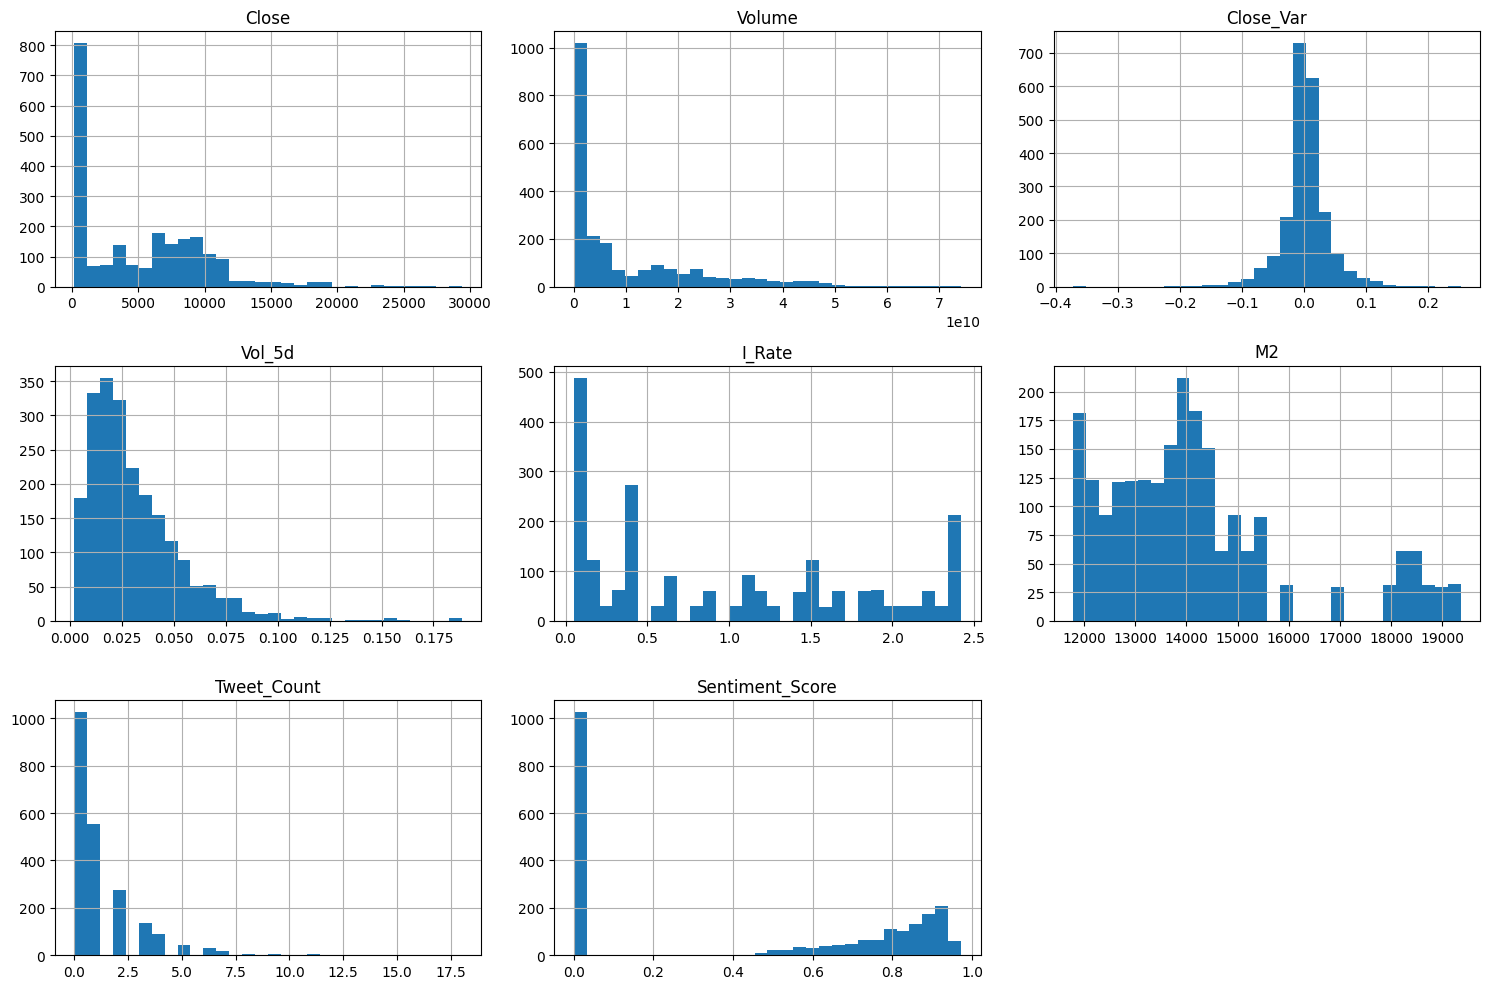

In [ ]:
# Graficamos las variables

variables = ['Close','Volume','Close_Var',
             'Vol_5d','I_Rate','M2',
             'Tweet_Count','Sentiment_Score']
columns = 3

df_clean[variables].hist(bins=30, figsize=(15, 10))
plt.tight_layout()
plt.show()

In [ ]:
# Definimos el dataframe sentimientos

sentimientos = df_clean["Sentiment"].value_counts().reset_index()
sentimientos.columns = ["Sentiment", "Count"]

# Graficamos con Plotly la distribucion del sentimiento diario
fig = px.bar(
    sentimientos,
    x="Sentiment",
    y="Count"
)
fig.update_layout(
    title="Distribución del sentimiento diario respecto a los tweets de Donald Trump",
    xaxis_title="Sentimiento",
    yaxis_title="Cantidad de días"
)
fig.show()

Notamos una predominancia de sentimiento neutral diario por sobre el sentimiento negativo y positivo. No esta de mas decir que parte de este sentimiento neutral esta "sesgado" por los dias donde no hubo tweets de Donald Trump relacionados al sector economico y financiero, y atribuimos un sentimiento neutral a dichos dias sin tweets.

In [ ]:
# Graficamos en Plotly un boxplot para la variacion porcentual diaria "Close_Var"
fig = px.box(df_clean, x="Close_Var")
fig.update_layout(
    title="Distribucion de la variacion porcentual diaria de Bitcoin",
    xaxis_title="Variacion porcentual diaria"
    )
fig.show()

En este boxplot podemos ver como se distribuyen los datos de la variacion porcentual por dia, y encontramos que:
- La mediana es de 0,21%
- En el rango intercuartilico IQR entre Q1 y Q3 la variacion de Bitcoin es entre -1,17% y 1,74%
- El bigote inferior esta delimitado por un -5,4% y el bigote superior por un 6,03%
- Las variaciones extremas negativa y positiva corresponden a -37.1% y 25,2% respectivamente.

Estos no son errores de computo sino que son eventos reales. La presencia de numerosos outliers refleja la alta volatilidad inherente al mercado de Bitcoin, por lo tanto optaremos por no reemplazar o eliminar estos outliers.

In [ ]:
# Graficamos en Plotly la variacion porcentual del dia del Bitcoin
fig = px.area(df_clean, x='Date', y="Close_Var")
fig.update_layout(
    title="Evolucion de la variacion porcentual diaria de Bitcoin",
    xaxis_title="Fecha",
    yaxis=dict(title="Variacion porcentual")
    )
# Agregamos el "range slider" para elegir el rango de fechas
fig.update_xaxes(rangeslider_visible=True)
fig.show()

Este grafico nos permite ver en una serie de tiempo lo que corroboramos en el boxplot, la mayor parte del tiempo el retorno diario es pequeño y cercano a cero, pero ocasionalmente ocurren eventos extremos impredecibles.

In [ ]:
# Graficamos en Plotly la evolucion del Bitcoin en contraste con los tweets de Donald Trump
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=df_clean["Date"],
    y=df_clean["Close"],
    name="BTC Precio de cierre",
    yaxis="y1"
))

fig.add_trace(go.Bar(
    x=df_clean["Date"],
    y=df_clean["Tweet_Count"],
    name="Cantidad de tweets",
    yaxis="y2",
))

fig.update_layout(
    title="Evolucion del precio del Bitcoin y los tweets de Donald Trump",
    xaxis_title="Fecha",
    yaxis=dict(title="BTC Precio (USD)"),
    yaxis2=dict(
        title="Cantidad de tweets",
        overlaying="y",
        side="right"
    )
)
# Agregamos el "range slider" para elegir el rango de fechas
fig.update_xaxes(rangeslider_visible=True)
fig.show()

Analizando el grafico, podemos notar ciertos periodos distintos:
- Desde Enero-2015 hasta Mayo-2018 no se distingue una correlacion clara entre la cantidad de tweets y el precio del Bitcoin.
- Desde Junio-2018 hasta Octubre-2020 podriamos llegar a encontrar cierta correlacion entre estas variables. Sin embargo, esto no confirma una relacion directa.
- Desde Noviembre-2020 hasta Enero-2021 hay definitivamente un quiebre: una disminucion pronunciada de tweets y un aumento significativo del precio del Bitcoin. Esto tampoco confirma una relacion inversa directa.

In [ ]:
# Graficamos en Plotly la evolucion de la volatibilidad futura a 5 dias en contraste con los tweets de Donald Trump
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=df_clean["Date"],
    y=df_clean["Vol_5d"],
    name="BTC Volatibilidad",
    yaxis="y1"
))

fig.add_trace(go.Bar(
    x=df_clean["Date"],
    y=df_clean["Tweet_Count"],
    name="Cantidad de tweets",
    yaxis="y2",
))

fig.update_layout(
    title="Evolucion de la volatibilidad a 5 dias de Bitcoin y los tweets de Donald Trump",
    xaxis_title="Fecha",
    yaxis=dict(title="BTC Volatibilidad a 5 dias"),
    yaxis2=dict(
        title="Cantidad de tweets",
        overlaying="y",
        side="right"
    )
)
# Agregamos el "range slider" para elegir el rango de fechas
fig.update_xaxes(rangeslider_visible=True)
fig.show()

In [ ]:
fig = px.box(
    df_clean,
    x="Tweet_Count",
    y="Close_Var",
    title="Variacion porcentual segun la cantidad de tweets por dia",
    labels={
        "Tweet_Count": "Tweets por dia",
        "Close_Var": "Variacion porcentual"
    }
)
fig.show()


Podemos ver algo muy similar a cuando analizamos la variacion porcentual individualmente: las variaciones porcentuales se ubican dentro de un rango entre -0.1 y 0.1, y una mayor cantidad de tweets no parece tener algun impacto en estas variaciones.

In [ ]:
fig = px.box(
    df_clean,
    x="Tweet_Count",
    y="Vol_5d",
    title="Volatibilidad futura a 5 dias segun la cantidad de tweets diarios",
    labels={
        "Tweet_Count": "Tweets por dia",
        "Vol_5d": "Volatibilidad a 5 dias"
    }
)
fig.show()


Los dias con mayor volatibilidad se encuentran en los dias que hubo de 0 a 3 tweets; el resto de los dias la volatibilidad se mantuvo dentro de los rangos normales. A simple vista, no podriamos definir una correlacion clara entre la cantidad de tweets diarios y volatibilidad.

In [ ]:
# Definimos el dataset que nos interesa analizar
df_num = df_clean.copy()
df_num.drop(columns=['Date','Open', 'High', 'Low', 'Sentiment'], inplace=True)

# Buscamos la correlacion con .corr()
corr = df_num.corr().round(3)
corr

# Graficamos el mapa de calor Heatmap de correlaciones
fig = ff.create_annotated_heatmap(
    z=corr.values,
    x=list(corr.columns),
    y=list(corr.index),
    colorscale="RdBu",
    showscale=True
)

fig.update_layout(
    title="Mapa de calor - Coeficientes de correlacion de Pearson",
    template="plotly_white"
)

fig.show()


Este mapa de calor es muy interesante, ya que nos revela las correlaciones entre las distintas variables, y confirma algunas sospechas:
- La variacion porcentual diara "Close_Var" tiene correlaciones bajas con todas las variables, podriamos considerarla una variable de random walk.
- No encontramos una correlacion fuerte para la tasa de interes.
- Hay una correlacion positiva fuerte entre el volumen financiero y el precio de cierre, y esto podria explicarse porque el volumen se mueve por la adopcion de Bitcoin como activo de reserva o especulativo.
- El puntaje de sentimiento muestra una correlacion positiva con la cantidad de tweets diarios, aunque esto no resulta muy interesante para nuestro proyecto.
- Podemos notar una correlacion positiva fuerte entre la oferta monetaria M2  y el precio de cierre Close: esto podria deberse a que ambos son dos series crecientes, y que una mayor masa monetaria de la FED implica una apreciacion de otras divisas. Sin embargo, esto no significa que M2 sea un buen predictor del precio Close, sino mas bien explica una tendencia.

# EDA con YData Profiling

In [ ]:
# Instalamos ydata-profiling

!pip install ydata-profiling


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 398.7/398.7 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 65.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 26.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 3.3 MB/s eta 0:00:00


In [ ]:
# Importamos

from ydata_profiling import ProfileReport

# Generamos la variable de reporte

profile = ProfileReport(df_clean, title="Profiling Report")

In [ ]:
profile

Output hidden; open in https://colab.research.google.com to view.

Las variables macroeconómicas parecen influir en el comportamiento de Bitcoin a nivel de tendencia, pero no muestran poder predictivo significativo en frecuencia diaria. Esto es consistente con la idea de que los mercados financieros descuentan la información macro con anticipacion.

El análisis de correlación muestra que los retornos diarios de Bitcoin (Close_Var) no presentan una relación significativa con ninguna de las variables consideradas. Este resultado es consistente con la literatura financiera, donde los retornos de alta frecuencia tienden a comportarse como ruido y presentan baja correlacion con factores observables.

A pesar del resultado, podemos notar varios puntos que podrian afectar el analisis:
- Cuando usamos una mascara para filtrar los tweets, este depende de palabras arbitrarias relacionadas al ambito economico y financiero, sin embargo algunos tweets excluidos podrian llegar a tener un impacto en el analisis.
- Al mismo tiempo, tweets que incluyan algunas de las palabras del filtro pero que no esten relacionados con el ambito economico y financiero tambien podrian  llegar a tener un impacto no deseado en el analisis.
- Los modelos de sentimiento son representativos del sentimiento pero eso no significa que esten relacionados necesariamente al ambito economico y financiero.

# Modelo explicativo OLS

Nuestra variable objetivo sera la volatibilidad en 5 dias 'Vol_5d'.

In [ ]:
X = df_clean[['Close','Volume','I_Rate','M2','Tweet_Count','Sentiment_Score','Sentiment']]
y = df_clean['Vol_5d']

Dado el reducido numero de variables explicativas y la baja correlacion entre ellas, no consideramos necesario reducir la dimensionalidad.

Primero, nos enfocaremos en entrenar un modelo explicativo con la libreria statsmodels.api y usar el modelo de minimos cuadrados ordinarios OLS.

In [ ]:
# Importamos la libreria
import statsmodels.api as sm

# Hacemos una copia de los datos
X_OLS = X.copy()
y_OLS = y.copy()

# Agregamos una variable constante a X para el intercepto del modelo
X_OLS = sm.add_constant(X_OLS)

In [ ]:
# Hacemos get_dummies para la columna Sentiment
X_OLS = pd.get_dummies(X_OLS, columns=["Sentiment"], drop_first = True)

# Nos aseguramos que las variables sean numeros
X_OLS[["Sentiment_neutral", "Sentiment_positive"]] = (X_OLS[["Sentiment_neutral", "Sentiment_positive"]].astype(int))

# Head
X_OLS.head()

,const,Close,Volume,I_Rate,M2,Tweet_Count,Sentiment_Score,Sentiment_neutral,Sentiment_positive
0,1.0,314.248993,8036550,0.11,11787.8,0.0,0.000000,1,0
1,1.0,315.032013,7860650,0.11,11787.8,1.0,0.818184,1,0
2,1.0,281.082001,33054400,0.11,11787.8,0.0,0.000000,1,0
3,1.0,264.195007,55629100,0.11,11787.8,0.0,0.000000,1,0
4,1.0,274.473999,43962800,0.11,11787.8,0.0,0.000000,1,0


Las variables dummy fueron convertidas a formato numérico para garantizar la correcta estimación del modelo OLS.

In [ ]:
# Entrenamos el modelo explicativo
modelo_OLS = sm.OLS(y_OLS, X_OLS).fit()

In [ ]:
# Hacemos .summary()
modelo_OLS.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 Vol_5d   R-squared:                       0.102
Model:                            OLS   Adj. R-squared:                  0.099
Method:                 Least Squares   F-statistic:                     31.03
Date:                Thu, 25 Dec 2025   Prob (F-statistic):           2.07e-46
Time:                        03:39:52   Log-Likelihood:                 5260.7
No. Observations:                2193   AIC:                        -1.050e+04
Df Residuals:                    2184   BIC:                        -1.045e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
======================================================================================
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  0.1022      0.007     14.875      0.000       0.089       0.116
Close               2.163e-06   1.82e-07     11.914      0.000    1.81e-06    2.52e-06
Volume              3.189e-13   6.49e-14      4.916      0.000    1.92e-13    4.46e-13
I_Rate              9.619e-05      0.001      0.151      0.880      -0.001       0.001
M2                 -6.179e-06   5.17e-07    -11.951      0.000   -7.19e-06   -5.17e-06
Tweet_Count           -0.0007      0.000     -1.849      0.065      -0.002    4.43e-05
Sentiment_Score        0.0018      0.002      1.071      0.284      -0.002       0.005
Sentiment_neutral      0.0024      0.002      1.474      0.141      -0.001       0.005
Sentiment_positive     0.0037      0.002      1.875      0.061      -0.000       0.007
==============================================================================
Omnibus:                     1002.809   Durbin-Watson:                   0.272
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             6499.664
Skew:                           2.063   Prob(JB):                         0.00
Kurtosis:                      10.356   Cond. No.                     2.42e+11
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.42e+11. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

Esto lo podemos interpretar de la siguiente forma:
- El coeficiente R-squared nos muestra que el modelo explica aproximadamente el 10% de la variable objetivo 'Vol_5d'.
- En conjunto, las variables de X tienen relación con la variable 'Vol_5d' aunque el efecto es limitado.
- Las variables que presentan un valor p menor a 0.05 son significativas: Close, Volume, y M2.
- Las variables que presentan un valor p entre 0.05 y 0.1 son casi significativas porque muestran evidencia debil: Tweet_Count, Sentiment_positive.
- Las variables que presentan un valor p mayor a 0.1 no son significativas: I_Rate, Sentiment_Score, Sentiment_neutral.
- Durbin-Watson muestra que hay autocorrelacion, normal en series temporales, de 0.274
- El error de modelo (valores reales - predicciones) no es normal, presenta asimetria y colas pesadas.
- Cond. No. muy alto nos muestra que hay escalas muy distintas y posible colinealidad.

Podemos decir que el OLS confirma rasgos y patrones que el analisis exploratorio nos anticipaba.

# Modelo: Regresion Lineal

Para entrenar estos modelos predictivos, primero usaremos train_test_split de la libreria scikit-learn para dividir los datos en una parte de entrenamiento (train) y prueba (test). Como trabajamos con una serie de tiempo, usaremos shuffle=False para no mezclar pasado con futuro.

In [ ]:
# Importamos la siguiente liberia
from sklearn.model_selection import train_test_split

# Terminamos de preparar los datos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=False)

Antes de comenzar, obtenemos las dummies de la variable categorica 'Sentiment'. Como vamos a entrenar un modelo de regresion lineal, es necesario que las variables sean numericas, que cada variable sea independiente, y no haya multicolinealidad entre ellas. Por eso, usaremos drop_first = True.

In [ ]:
# Hacemos .get_dummies()
X_train = pd.get_dummies(X_train, columns=["Sentiment"], drop_first = True)
X_test = pd.get_dummies(X_test, columns=["Sentiment"], drop_first = True)

# Asegurar mismas columnas
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

Ahora normalizamos las variables explicativas utilizando la estandarizacion del z-score con el fin de evitar distorsiones derivadas de diferencias de escala.

In [ ]:
# Importamos la libreria para normalizar las variables X
from sklearn.preprocessing import StandardScaler

# Definimos la variable scaler
sc = StandardScaler()

# Normalizamos las variables
X_train_sc = sc.fit_transform(X_train)
X_test_sc = sc.transform(X_test)

Definimos el modelo de regresion lineal.

In [ ]:
# Importamos la liberia de regresion lineal
from sklearn.linear_model import LinearRegression

# Definimos el modelo
modelo_LR = LinearRegression()

Usaremos TimeSeriesSplit como validacion cruzada, ya que estamos trabajando con una serie de tiempo. (Esto difiere de otros tipos de datasets que trabajan mejor con otros tipos de validacion cruzada, como K Folds).

In [ ]:
# Importamos la libreria de TimeSeriesSplit
from sklearn.model_selection import TimeSeriesSplit

# Definimos tscv
tscv = TimeSeriesSplit(n_splits=5)

In [ ]:
# Importamos la libreria de validacion cruzada
from sklearn.model_selection import cross_val_score

# Definimos cv_lr
cv_lr = cross_val_score(
    modelo_LR,
    X_train_sc,
    y_train,
    cv=tscv,
    scoring="neg_mean_absolute_error"
)

print("Error medio absoluto, por fold:", -cv_lr)
print("Error medio absoluto, promedio de folds:", -cv_lr.mean())
print("Desvio de los folds:", cv_lr.std())

Error medio absoluto, por fold: [0.0168497  0.03930097 0.21719806 0.04940296 0.03168958]
Error medio absoluto, promedio de folds: 0.07088825279612945
Desvio de los folds: 0.07392244049606311


Ahora entrenamos el modelo de regresion lineal, y realizamos las predicciones.

In [ ]:
# Entrenamos el modelo
modelo_LR.fit(X_train_sc, y_train)

# Usamos el modelo para predecir X_test_sc y definimos la variable y_pred
y_pred = modelo_LR.predict(X_test_sc)

Ahora evaluamos el modelo con las siguientes metricas.

In [ ]:
# Error medio absoluto MAE
from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(y_test, y_pred)

# Error medio cuadratico MSE
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(y_test, y_pred)
# Raiz del error medio cuadratico
rmse = np.sqrt(mse)

# Coeficiente de determinacion R cuadrado
from sklearn.metrics import r2_score
r2 = r2_score(y_test, y_pred)

# Print
print ('El error medio absoluto es:',mae)
print ('La raiz del error medio cuadratico es:',rmse)
print ('El coeficiente de determinacion es:',r2)

El error medio absoluto es: 0.01767056060754534
La raiz del error medio cuadratico es: 0.024737107385383428
El coeficiente de determinacion es: -0.18215763587115497


El coeficiente de determinación negativo indica que el modelo no logra mejorar una predicción basada en el promedio histórico, lo cual refuerza la hipótesis de que las variables consideradas poseen una capacidad predictiva limitada sobre el comportamiento de Bitcoin en el corto plazo.

In [ ]:
# Creamos un dataframe y comparamos el valor real y la prediccion

df_LR = pd.DataFrame({'Real': y_test, 'Prediccion': y_pred})
df_LR['Error'] = df_LR['Real'] - df_LR['Prediccion']
df_LR.sort_values(by='Error', ascending=False)

,Real,Prediccion,Error
1895,0.188591,0.038453,0.150138
1894,0.184572,0.037212,0.147360
1896,0.185943,0.039139,0.146803
1893,0.185467,0.040082,0.145386
1892,0.157751,0.041224,0.116527
...,...,...,...
2189,0.036589,0.078785,-0.042197
2188,0.038013,0.081848,-0.043835
2177,0.030690,0.077030,-0.046340
2186,0.023786,0.074274,-0.050489


In [ ]:
# Graficamos en Plotly un boxplot para la distribucion de errores

import plotly.express as px
fig = px.box(df_LR, x="Error")
fig.update_layout(
    title="Distribucion de Errores - Diferencia entre valor real y prediccion",
    xaxis_title="Valor real - Valor predecido"
    )
fig.show()

La distribución de los errores muestra una mediana cercana a cero y una asimetría positiva con presencia de outliers, indicando que el modelo no presenta un sesgo sistemático, pero tiene dificultades para capturar movimientos extremos del mercado, lo cual es consistente con la naturaleza volátil de Bitcoin.

# Modelo: Ridge Regression

In [ ]:
# Importamos las librerias
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Ridge

# Modelo Ridge
modelo_R = Ridge()

# Definimos los parametros
params_R = {
    "alpha": [0.001, 0.01, 0.1, 1, 10, 100, 1000]
}

# Optimizamos los parametros con GridSearchCV
grid_R = GridSearchCV(
    modelo_R,
    params_R,
    cv=tscv,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)

grid_R.fit(X_train_sc, y_train)

print("Mejores parametros:", grid_R.best_params_)
print("Mejor error medio absoluto de validacion cruzada:", -grid_R.best_score_)


Mejores parametros: {'alpha': 1000}
Mejor error medio absoluto de validacion cruzada: 0.019642399249652026


Se realizó un ajuste de hiperparámetros utilizando validación cruzada con el fin de evaluar si una configuración alternativa del modelo podía mejorar el desempeño. Los resultados muestran mejoras marginales, sin modificar las conclusiones principales del trabajo.

El proceso de validación cruzada seleccionó un valor elevado del parámetro de regularización, indicando la presencia de ruido y una señal predictiva débil en las variables explicativas.

In [ ]:
# Definimos para evaluar el modelo
mejor_modelo_R = grid_R.best_estimator_

# Usamos el modelo para predecir
y_pred_R = mejor_modelo_R.predict(X_test_sc)

In [ ]:
# Importamos metricas
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Obtenemos el error medio absoluto
mae_R = mean_absolute_error(y_test, y_pred_R)

# Obtenemos el error medio cuadratico
mse_R = mean_squared_error(y_test, y_pred_R)
# Raiz rmse
rmse_R = np.sqrt(mse_R)

# Obtenemos el coeficiente de correlacion
r2_R = r2_score(y_test, y_pred_R)

print ('El error medio absoluto es:',mae_R)
print ('La raiz del error medio cuadratico es:',rmse_R)
print ('El coeficiente de determinacion es:',r2_R)

El error medio absoluto es: 0.02192600349065487
La raiz del error medio cuadratico es: 0.027230268293589852
El coeficiente de determinacion es: -0.43245637249558544


El segundo modelo evaluado presenta un desempeño inferior, con errores mayores y un coeficiente de determinación más negativo, indicando que su capacidad predictiva es menor y que introduce mayor ruido en la prediccion.

In [ ]:
# Creamos un dataframe y comparamos el valor real y la prediccion

pred_R = pd.DataFrame({'Real': y_test, 'Prediccion': y_pred_R})
pred_R['Error'] = pred_R['Real'] - pred_R['Prediccion']
pred_R.sort_values(by='Error', ascending=False)

,Real,Prediccion,Error
1895,0.188591,0.044860,0.143731
1896,0.185943,0.044284,0.141659
1893,0.185467,0.044885,0.140583
1894,0.184572,0.045860,0.138712
1892,0.157751,0.044643,0.113108
...,...,...,...
2177,0.030690,0.071137,-0.040447
2098,0.009571,0.050665,-0.041095
2186,0.023786,0.065104,-0.041318
2096,0.010121,0.052917,-0.042796


In [ ]:
# Graficamos en Plotly un boxplot para la distribucion de errores

import plotly.express as px
fig = px.box(pred_R, x="Error")
fig.update_layout(
    title="Distribucion de Errores - Diferencia entre valor real y prediccion",
    xaxis_title="Valor real - Valor predecido"
    )
fig.show()

La distribución de errores del segundo modelo presenta mayor dispersión, una mediana más alejada de cero y outliers más extremos, lo cual confirma su menor desempeño predictivo en comparación con el modelo anterior.

# Modelo: XGB Regressor

In [ ]:
# Importamos las librerias
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import TimeSeriesSplit
from xgboost import XGBRegressor

# Definimos el modelo XGB Regressor
modelo_xgb = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    tree_method="hist"
)

# Parametros del modelo
params_xgb = {
    "xgb__n_estimators": [200, 500],
    "xgb__max_depth": [2, 3, 5],
    "xgb__learning_rate": [0.03, 0.1],
    "xgb__subsample": [0.8, 1.0],
    "xgb__colsample_bytree": [0.8, 1.0],
    "xgb__reg_lambda": [1, 10],
    "xgb__reg_alpha": [0, 0.1]
}

# GridSearchCV
grid_xgb = GridSearchCV(
    estimator=modelo_xgb,
    param_grid=params_xgb,
    cv=tscv,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    verbose=1
)

# Entrenamos
grid_xgb.fit(X_train_sc, y_train)

# Print
print("Mejores parametros:", grid_xgb.best_params_)
print("Mejor error medio absoluto de validacion cruzada:", grid_xgb.best_score_)

Fitting 5 folds for each of 192 candidates, totalling 960 fits
Mejores parametros: {'xgb__colsample_bytree': 0.8, 'xgb__learning_rate': 0.03, 'xgb__max_depth': 2, 'xgb__n_estimators': 200, 'xgb__reg_alpha': 0, 'xgb__reg_lambda': 1, 'xgb__subsample': 0.8}
Mejor error medio absoluto de validacion cruzada: -0.02170387376123334


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning:

[03:43:02] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "xgb__colsample_bytree", "xgb__learning_rate", "xgb__max_depth", "xgb__n_estimators", "xgb__reg_alpha", "xgb__reg_lambda", "xgb__subsample" } are not used.




In [ ]:
# Definimos para evaluar el modelo
mejor_modelo_xgb = grid_xgb.best_estimator_

# Usamos el modelo para predecir
y_pred_xgb = mejor_modelo_xgb.predict(X_test_sc)

In [ ]:
# Importamos metricas
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Obtenemos el error medio absoluto
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)

# Obtenemos el error medio cuadratico
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
# Raiz rmse
rmse_xgb = np.sqrt(mse_xgb)

# Obtenemos el coeficiente de correlacion
r2_xgb = r2_score(y_test, y_pred_xgb)

print ('El error medio absoluto es:',mae_xgb)
print ('La raiz del error medio cuadratico es:',rmse_xgb)
print ('El coeficiente de determinacion es:',r2_xgb)


El error medio absoluto es: 0.02914622298465423
La raiz del error medio cuadratico es: 0.03468178557401926
El coeficiente de determinacion es: -1.3237021545573286


In [ ]:
# Creamos un dataframe y comparamos el valor real y la prediccion

pred_xgb = pd.DataFrame({'Real': y_test, 'Prediccion': y_pred_xgb})
pred_xgb['Error'] = pred_xgb['Real'] - pred_xgb['Prediccion']
pred_xgb.sort_values(by='Error', ascending=False)

,Real,Prediccion,Error
1894,0.184572,0.070499,0.114073
1895,0.188591,0.074587,0.114003
1896,0.185943,0.084056,0.101887
1893,0.185467,0.086077,0.099390
1755,0.083711,0.018820,0.064891
...,...,...,...
1916,0.019305,0.089977,-0.070672
2006,0.008554,0.080339,-0.071785
2022,0.003897,0.078643,-0.074747
2018,0.004289,0.080550,-0.076261


In [ ]:
# Graficamos en Plotly un boxplot para la distribucion de errores

import plotly.express as px
fig = px.box(pred_xgb, x="Error")
fig.update_layout(
    title="Distribucion de Errores - Diferencia entre valor real y prediccion",
    xaxis_title="Valor real - Valor predecido"
    )
fig.show()

Este modelo mas complejo de XGBoost, presento un desempeño significativamente peor, lo que refuerza la hipótesis de que la información contenida en los tweets no posee capacidad predictiva real y que los modelos tienden a sobreajustar ruido.

# Conclusion

Primero generamos un dataframe que compare los valores reales y las predicciones de los distintos modelos.

In [ ]:
# Creamos un dataframe y comparamos el valor real y la prediccion

real_prediccion = pd.DataFrame({'Real': y_test, 'Prediccion LR': y_pred,'Prediccion Ridge': y_pred_R,'Prediccion XGB': y_pred_xgb})
real_prediccion.sort_values(by='Real', ascending=False)

,Real,Prediccion LR,Prediccion Ridge,Prediccion XGB
1895,0.188591,0.038453,0.044860,0.074587
1896,0.185943,0.039139,0.044284,0.084056
1893,0.185467,0.040082,0.044885,0.086077
1894,0.184572,0.037212,0.045860,0.070499
1892,0.157751,0.041224,0.044643,0.107010
...,...,...,...,...
2020,0.003922,0.025059,0.040093,0.074050
2022,0.003897,0.023137,0.037451,0.078643
2017,0.003794,0.024142,0.038061,0.039255
2019,0.003658,0.022332,0.037001,0.044376


Al comparar los valores reales con las predicciones de los distintos modelos, se observa que todos tienden a subestimar sistemáticamente los eventos de mayor magnitud, concentrando sus predicciones en un rango reducido. Esto indica que las variables utilizadas no contienen información suficiente para anticipar movimientos extremos del mercado.

Se construyó un dataframe comparativo con las métricas MAE, RMSE y R² para los distintos modelos evaluados. Los resultados muestran que la regresión lineal presenta el mejor desempeño relativo, mientras que modelos más complejos como XGBoost obtienen peores resultados, lo que refuerza la ausencia de señal predictiva en las variables utilizadas.

In [ ]:
df_metricas = pd.DataFrame({
    "Modelo": ["Linear Regression", "Ridge Regression", "XGBoost"],
    "MAE": [mae, mae_R, mae_xgb],
    "RMSE": [rmse, rmse_R, rmse_xgb],
    "R2": [r2, r2_R, r2_xgb]
})

df_metricas

,Modelo,MAE,RMSE,R2
0,Linear Regression,0.017671,0.024737,-0.182158
1,Ridge Regression,0.021926,0.027230,-0.432456
2,XGBoost,0.029146,0.034682,-1.323702




El objetivo de este trabajo fue analizar si los tweets de Donald Trump tienen algún impacto significativo sobre el comportamiento del mercado de Bitcoin, particularmente en términos de variacion porcentual y volatilidad en el corto plazo.

A partir del analisis exploratorio de los datos y la aplicacion de distintos enfoques de modelado, tanto explicativos como predictivos, no encontramos evidencia robusta que indique que los tweets de Donald Trump constituyan un determinante relevante del precio o la volatilidad de Bitcoin. Si bien algunas variables relacionadas con la actividad en Twitter, como la cantidad de tweets y el sentimiento positivo, mostraron asociaciones débiles en ciertos modelos, estos efectos no resultaron consistentes ni suficientemente significativos como para sostener una relacion solida.

Por el contrario, las variables de mercado y macroeconómicas, como el precio, el volumen de operaciones y la oferta monetaria M2, presentaron una mayor capacidad explicativa, lo cual sugiere que el comportamiento de Bitcoin está principalmente influenciado por dinámicas propias del mercado y por factores estructurales más amplios, en lugar de eventos comunicacionales aislados.

Los distintos modelos utilizados (regresión lineal, Ridge y XGBoost) convergieron en conclusiones similares, reforzando la idea de que la señal contenida en los tweets analizados es limitada y altamente ruidosa. Asimismo, la utilización de validación cruzada con particiones temporales permitió obtener una evaluacion mas realista del desempeño predictivo, evidenciando la dificultad inherente de anticipar movimientos financieros en mercados altamente volatiles.

En este sentido, los resultados obtenidos no deben interpretarse como un fracaso del análisis, sino como una confirmación empírica de la complejidad y eficiencia relativa de los mercados financieros. El valor del trabajo reside en la correcta formulación del problema, el uso adecuado de metodologías de series temporales y la interpretación crítica de los resultados.